In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from river import tree, metrics
import pickle
import mlflow

cols = ['unit', 'cycle', 'op1', 'op2', 'op3'] + [f's{i}' for i in range(1, 22)]
df = pd.read_csv('../data/train_FD001.txt', sep=r'\s+', header=None, names=cols)
print(f"Loaded: {df.shape}")
print(f"Engines: {df['unit'].nunique()}")

Loaded: (20631, 26)
Engines: 100


In [2]:
max_cycle = df.groupby('unit')['cycle'].max().reset_index()
max_cycle.columns = ['unit', 'max_cycle']
df = df.merge(max_cycle, on='unit')
df['RUL'] = df['max_cycle'] - df['cycle']
df.drop('max_cycle', axis=1, inplace=True)

sensor_cols = [f's{i}' for i in range(1, 22)]
constant_sensors = [c for c in sensor_cols if df[c].std() == 0]
df.drop(columns=constant_sensors, inplace=True)
active_sensors = [c for c in df.columns if c.startswith('s')]

print(f"Dropped: {constant_sensors}")
print(f"Active sensors: {len(active_sensors)}")
print(f"Shape: {df.shape}")

df.to_csv('../outputs/clean_data.csv', index=False)

Dropped: ['s1', 's10', 's18', 's19']
Active sensors: 17
Shape: (20631, 23)


In [3]:
all_units = sorted(df['unit'].unique())
np.random.seed(42)
np.random.shuffle(all_units)

train_units = all_units[:70]
test_units  = all_units[70:]

train_df = df[df['unit'].isin(train_units)].copy().reset_index(drop=True)
test_df  = df[df['unit'].isin(test_units)].copy().reset_index(drop=True)

print(f"Train: {train_df.shape}")
print(f"Test:  {test_df.shape}")

train_df.to_csv('../outputs/train_clean.csv', index=False)
test_df.to_csv('../outputs/test_clean.csv', index=False)

Train: (14316, 23)
Test:  (6315, 23)


In [4]:
X_train = train_df[active_sensors].values
y_train = train_df['RUL'].values
X_test_clean = test_df[active_sensors].values
y_test_clean = test_df['RUL'].values

static_model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
static_model.fit(X_train, y_train)

static_preds_clean = static_model.predict(X_test_clean)
static_rmse_clean = np.sqrt(mean_squared_error(y_test_clean, static_preds_clean))
static_mae_clean  = mean_absolute_error(y_test_clean, static_preds_clean)

print(f"Static RMSE (clean): {static_rmse_clean:.2f}")
print(f"Static MAE  (clean): {static_mae_clean:.2f}")

with open('../outputs/static_model.pkl', 'wb') as f:
    pickle.dump(static_model, f)

Static RMSE (clean): 44.00
Static MAE  (clean): 32.77


In [5]:
drifted_datasets = {}

for level_name, noise_rate in [("Low", 0.001), ("High", 0.010)]:
    np.random.seed(42)
    drifted = test_df.copy()
    for col in active_sensors:
        s = train_df[col].std()
        noise = np.random.normal(0, noise_rate * (test_df['cycle'] ** 1.5) * s, len(test_df))
        drifted[col] = test_df[col] + noise
    drifted_datasets[level_name] = drifted
    drifted.to_csv(f'../outputs/test_drifted_{level_name.lower()}.csv', index=False)
    print(f"{level_name} drift applied (rate={noise_rate})")

print("Both drifted datasets saved.")

Low drift applied (rate=0.001)
High drift applied (rate=0.01)
Both drifted datasets saved.


In [6]:
static_results = {}

for level_name, drifted in drifted_datasets.items():
    X_test = drifted[active_sensors].values
    y_test = drifted['RUL'].values
    preds = static_model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae  = mean_absolute_error(y_test, preds)
    static_results[level_name] = {"rmse": rmse, "mae": mae}
    print(f"Static | {level_name} drift | RMSE: {rmse:.2f} | MAE: {mae:.2f}")

Static | Low drift | RMSE: 56.81 | MAE: 43.38
Static | High drift | RMSE: 82.04 | MAE: 64.98


In [7]:
inc_results = {}
per_bin_data = {}

for level_name, drifted in drifted_datasets.items():
    print(f"\n{level_name} drift — training Hoeffding Tree...")

    inc_model = tree.HoeffdingTreeRegressor(
        grace_period=50, delta=0.01, leaf_prediction='mean', max_depth=6
    )

    train_shuffled = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
    for idx, row in train_shuffled.iterrows():
        inc_model.learn_one(row[active_sensors].to_dict(), row['RUL'])

    test_sorted = drifted.sort_values(['unit', 'cycle']).reset_index(drop=True)
    inc_metric = metrics.RMSE()
    inc_preds_list = []

    for idx, row in test_sorted.iterrows():
        x = row[active_sensors].to_dict()
        y = row['RUL']
        pred = inc_model.predict_one(x)
        if pred is not None:
            inc_metric.update(y, pred)
            inc_preds_list.append(pred)
        inc_model.learn_one(x, y)

    inc_rmse = inc_metric.get()
    inc_results[level_name] = {"rmse": inc_rmse}

    test_sorted['inc_pred'] = inc_preds_list
    test_sorted['inc_err_sq'] = (test_sorted['inc_pred'] - test_sorted['RUL']) ** 2
    test_sorted['static_pred'] = static_model.predict(drifted[active_sensors].values)
    test_sorted['static_err_sq'] = (test_sorted['static_pred'] - test_sorted['RUL']) ** 2
    per_bin_data[level_name] = test_sorted

    imp = (static_results[level_name]['rmse'] - inc_rmse) / static_results[level_name]['rmse'] * 100
    print(f"  Static:      {static_results[level_name]['rmse']:.2f}")
    print(f"  Incremental: {inc_rmse:.2f}")
    print(f"  Improvement: {imp:.1f}%")

    with open(f'../outputs/inc_model_{level_name.lower()}.pkl', 'wb') as f:
        pickle.dump(inc_model, f)


Low drift — training Hoeffding Tree...
  Static:      56.81
  Incremental: 56.99
  Improvement: -0.3%

High drift — training Hoeffding Tree...
  Static:      82.04
  Incremental: 66.65
  Improvement: 18.8%



SUMMARY
Drift    Static RMSE    Incremental RMSE   Improvement %  
------------------------------------------------------------------------
Low      56.81          56.99              -0.3           
High     82.04          66.65              18.8           


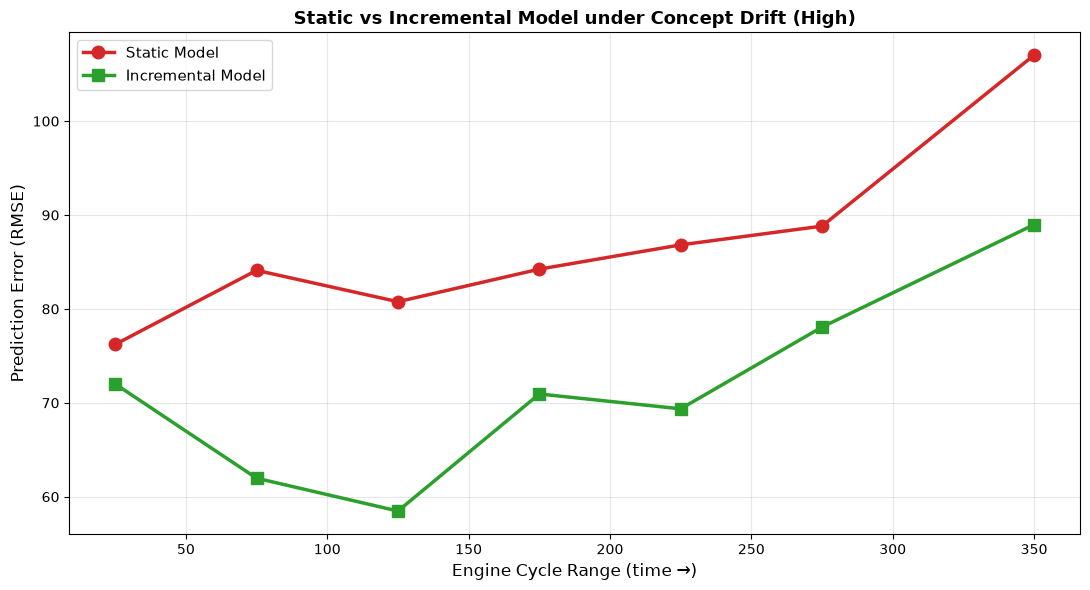

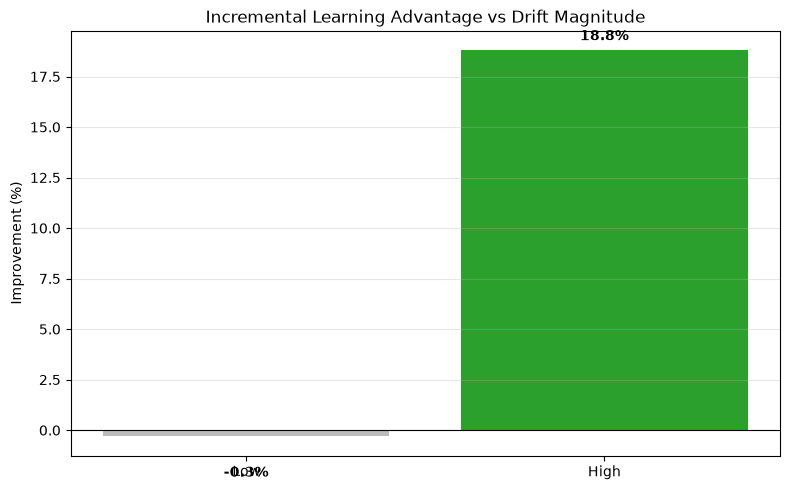

Saved graphs.


In [8]:
print("\n" + "=" * 72)
print("SUMMARY")
print("=" * 72)
print(f"{'Drift':<8} {'Static RMSE':<14} {'Incremental RMSE':<18} {'Improvement %':<15}")
print("-" * 72)
for level in ["Low", "High"]:
    s = static_results[level]['rmse']
    i = inc_results[level]['rmse']
    imp = (s - i) / s * 100
    print(f"{level:<8} {s:<14.2f} {i:<18.2f} {imp:<15.1f}")
print("=" * 72)

summary_df = pd.DataFrame([
    {
        "Drift": level,
        "Static RMSE": round(static_results[level]['rmse'], 2),
        "Incremental RMSE": round(inc_results[level]['rmse'], 2),
        "Improvement %": round(
            (static_results[level]['rmse'] - inc_results[level]['rmse'])
            / static_results[level]['rmse'] * 100, 1
        )
    }
    for level in ["Low", "High"]
])
summary_df.to_csv('../outputs/sensitivity_analysis.csv', index=False)

bins = [0, 50, 100, 150, 200, 250, 300, 400]
bin_midpoints = [25, 75, 125, 175, 225, 275, 350]

high_df = per_bin_data["High"].copy()
high_df['cycle_bin'] = pd.cut(high_df['cycle'], bins=bins)
static_per_bin = high_df.groupby('cycle_bin', observed=True)['static_err_sq'].mean().apply(np.sqrt)
inc_per_bin    = high_df.groupby('cycle_bin', observed=True)['inc_err_sq'].mean().apply(np.sqrt)

n = min(len(static_per_bin), len(inc_per_bin), len(bin_midpoints))
x  = bin_midpoints[:n]
sv = static_per_bin.values[:n]
iv = inc_per_bin.values[:n]

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(x, sv, marker='o', linewidth=2.5, markersize=9, color='#d62728', label='Static Model')
ax.plot(x, iv, marker='s', linewidth=2.5, markersize=9, color='#2ca02c', label='Incremental Model')
ax.set_xlabel('Engine Cycle Range (time →)', fontsize=12)
ax.set_ylabel('Prediction Error (RMSE)', fontsize=12)
ax.set_title('Static vs Incremental Model under Concept Drift (High)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/hero_comparison.png', dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
xpos = np.arange(len(summary_df))
ax.bar(xpos, summary_df['Improvement %'], color=['#bbbbbb', '#2ca02c'])
ax.set_xticks(xpos)
ax.set_xticklabels(summary_df['Drift'])
ax.set_ylabel('Improvement (%)')
ax.set_title('Incremental Learning Advantage vs Drift Magnitude')
ax.axhline(0, color='black', linewidth=0.8)
for i, v in enumerate(summary_df['Improvement %']):
    ax.text(i, v + 0.5 if v >= 0 else v - 2, f"{v:.1f}%", ha='center', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../outputs/sensitivity_bars.png', dpi=150)
plt.show()

print("Saved graphs.")

In [9]:
mlflow.set_tracking_uri("file:../mlruns")
mlflow.set_experiment("continual_learning_industrial")

with mlflow.start_run(run_name="final_run"):
    mlflow.log_param("train_engines", 70)
    mlflow.log_param("test_engines", 30)
    mlflow.log_param("active_sensors", len(active_sensors))

    for level in ["Low", "High"]:
        lvl = level.lower()
        mlflow.log_metric(f"static_rmse_{lvl}", static_results[level]['rmse'])
        mlflow.log_metric(f"inc_rmse_{lvl}", inc_results[level]['rmse'])
        mlflow.log_metric(f"improvement_{lvl}",
            (static_results[level]['rmse'] - inc_results[level]['rmse'])
            / static_results[level]['rmse'] * 100)

    mlflow.log_artifact("../outputs/hero_comparison.png")
    mlflow.log_artifact("../outputs/sensitivity_bars.png")
    mlflow.log_artifact("../outputs/sensitivity_analysis.csv")
    print(f"Run ID: {mlflow.active_run().info.run_id}")

print("DONE")

MlflowException: The filesystem tracking backend (e.g., './mlruns') is in maintenance mode and will not receive further updates. Please migrate to a database backend (e.g., 'sqlite:///mlflow.db') to access the latest MLflow features. The `mlflow migrate-filestore` tool migrates your existing data losslessly. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance. If the filesystem backend is required for your workflow, set `MLFLOW_ALLOW_FILE_STORE=true` to opt out of this exception.